In [4]:
# Generate Dataset Prediksi Kelulusan Mahasiswa
import pandas as pd
import numpy as np

# Set seed agar hasil bisa direproduksi
np.random.seed(42)

# Jumlah data: 500 (melebihi 300)
n = 500

# Fitur 1: IP Semester 1 (range 2.0 - 4.0)
ip_sem1 = np.random.uniform(2.0, 4.0, n).round(2)

# Fitur 2: IP Semester 2 (dipengaruhi IP sem1 + noise)
ip_sem2 = ip_sem1 + np.random.normal(0, 0.3, n)
ip_sem2 = np.clip(ip_sem2, 2.0, 4.0).round(2)

# Fitur 3: IP Semester 3
ip_sem3 = ip_sem2 + np.random.normal(0, 0.3, n)
ip_sem3 = np.clip(ip_sem3, 2.0, 4.0).round(2)

# Fitur 4: IP Semester 4
ip_sem4 = ip_sem3 + np.random.normal(0, 0.3, n)
ip_sem4 = np.clip(ip_sem4, 2.0, 4.0).round(2)

# Fitur 5: Jumlah mata kuliah tidak lulus (0-8)
mk_tidak_lulus = np.random.poisson(2, n)
mk_tidak_lulus = np.clip(mk_tidak_lulus, 0, 8)

# Fitur 6: Keaktifan organisasi (0=Tidak, 1=Ya)
organisasi = np.random.binomial(1, 0.4, n)

# Fitur 7: Beasiswa (0=Tidak, 1=Ya)
beasiswa = np.random.binomial(1, 0.3, n)

# Fitur 8: Kehadiran persentase (40% - 100%)
kehadiran = np.random.normal(80, 15, n)
kehadiran = np.clip(kehadiran, 40, 100).round(1)

# Target: Lulus Tepat Waktu (1) atau Tidak (0)
# Aturan: IP sem4 > 3.0, mk_tidak_lulus <= 2, kehadiran > 75
lulus_tepat = ((ip_sem4 > 3.0) & (mk_tidak_lulus <= 2) & (kehadiran > 75)).astype(int)

# Tambahkan sedikit noise (acak 5% data berubah label) agar realistis
noise = np.random.random(n) < 0.05
lulus_tepat[noise] = 1 - lulus_tepat[noise]

# Gabungkan ke DataFrame
df = pd.DataFrame({
    'IP_Semester1': ip_sem1,
    'IP_Semester2': ip_sem2,
    'IP_Semester3': ip_sem3,
    'IP_Semester4': ip_sem4,
    'Jumlah_MK_Tidak_Lulus': mk_tidak_lulus,
    'Organisasi': organisasi,
    'Beasiswa': beasiswa,
    'Kehadiran_Persen': kehadiran,
    'Lulus_Tepat_Waktu': lulus_tepat
})

# Simpan ke file CSV
df.to_csv('dataset_kelulusan.csv', index=False)

# Tampilkan 5 data pertama
print("Dataset berhasil dibuat dengan 500 baris.")
print(df.head())

# Cek distribusi kelas
print("\nDistribusi kelas (0=Tidak tepat waktu, 1=Tepat waktu):")
print(df['Lulus_Tepat_Waktu'].value_counts())

Dataset berhasil dibuat dengan 500 baris.
   IP_Semester1  IP_Semester2  IP_Semester3  IP_Semester4  \
0          2.75          2.85          3.03          3.42   
1          3.90          4.00          3.89          4.00   
2          3.46          3.75          3.93          3.94   
3          3.20          3.03          3.36          3.13   
4          2.31          2.04          2.29          2.43   

   Jumlah_MK_Tidak_Lulus  Organisasi  Beasiswa  Kehadiran_Persen  \
0                      1           1         0              57.0   
1                      1           1         0              77.1   
2                      3           1         0              84.5   
3                      0           0         1              82.6   
4                      1           1         0              52.3   

   Lulus_Tepat_Waktu  
0                  0  
1                  1  
2                  0  
3                  1  
4                  0  

Distribusi kelas (0=Tidak tepat waktu, 1=Te

In [5]:
# Preprocessing dan Persiapan Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Pisahkan fitur dan target
X = df.drop('Lulus_Tepat_Waktu', axis=1)
y = df['Lulus_Tepat_Waktu']

# Split training dan testing (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} data")
print(f"Testing set: {X_test.shape[0]} data")

# Scaling fitur numerik (semua fitur kecuali Organisasi & Beasiswa? Sebaiknya semua kontinu di-scale)
# Identifikasi kolom numerik kontinu
numeric_cols = ['IP_Semester1', 'IP_Semester2', 'IP_Semester3', 'IP_Semester4',
                'Jumlah_MK_Tidak_Lulus', 'Kehadiran_Persen']
# Kolom kategorikal biner: Organisasi, Beasiswa (tidak perlu discale, tapi scaling tidak masalah)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Kembalikan ke DataFrame agar mudah dilihat (opsional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nScaling selesai. Contoh data train setelah scaling:")
print(X_train_scaled.head())

Training set: 400 data
Testing set: 100 data

Scaling selesai. Contoh data train setelah scaling:
   IP_Semester1  IP_Semester2  IP_Semester3  IP_Semester4  \
0      0.212759      0.092946     -0.513740     -1.160480   
1     -0.708274     -0.660239      0.059723     -0.695283   
2      1.602681      1.631366      1.508472      1.030450   
3     -1.378117     -1.573676     -1.253206     -1.535639   
4      0.179267      0.637803      0.738824      1.465635   

   Jumlah_MK_Tidak_Lulus  Organisasi  Beasiswa  Kehadiran_Persen  
0               1.370405   -0.737836 -0.654654         -0.543994  
1              -0.019106   -0.737836 -0.654654         -0.152870  
2              -0.713861   -0.737836  1.527525          1.006533  
3              -1.408617    1.355315 -0.654654          0.056661  
4              -0.019106   -0.737836 -0.654654         -2.387863  


Akurasi: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        25

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



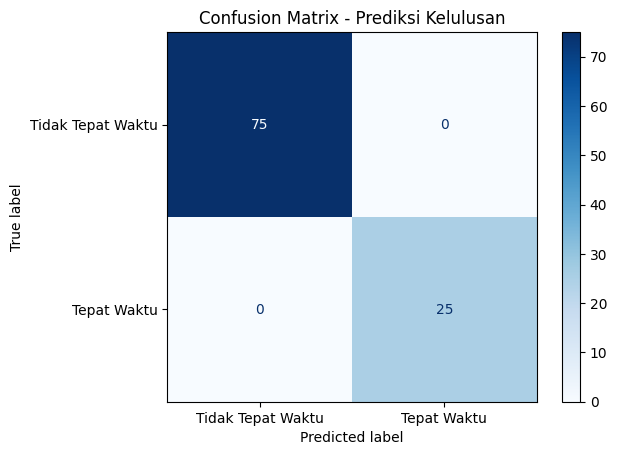

In [6]:
# Training model dengan class_weight untuk mengatasi imbalance
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Prediksi dan evaluasi
y_pred = model.predict(X_test_scaled)

# Hasil evaluasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Tepat Waktu', 'Tepat Waktu'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Prediksi Kelulusan')
plt.show()